In [1]:
import json

obj365_filenames = "/home/maelic/Documents/OpenVocSGG/all_annotations/O365 (pseudo)/image_id_to_filepath.json"

with open(obj365_filenames, 'r') as f:
    obj365_filenames = json.load(f)

print(obj365_filenames['900001'])

train/patch16/objects365_v2_00900001.jpg


In [11]:
print(obj365_filenames['36'])

train/patch0/objects365_v1_00000036.jpg


In [31]:
coco_path = "/home/maelic/Documents/OpenVocSGG/all_annotations/O365 (pseudo)/RLIPv2_o365trainval_Tagger2_Noi24_20e_Xattnmask_SceneGraph_model_large_caption_nucleus10_thre05_1234_4.json"

#coco_path = "/home/maelic/Documents/OpenVocSGG/all_annotations/COCO (pseudo)/RLIPv2_train2017_threshold20_Tagger2_Noi24_20e_Xattnmask_SceneGraph_model_large_caption_nucleus10_thre05.json"
generated_data = "/home/maelic/Documents/OpenVocSGG/generated_data/OV_SGG_dataset/data_COCO_llava_OV.json"
#generated_data = "/home/maelic/Documents/OpenVocSGG/all_annotations/COCO (pseudo)/RLIPv2_train2017_threshold20_Tagger2_Noi24_20e_Xattnmask_SceneGraph_model_large_caption_nucleus10_thre05.json"
coco_img_path = "/home/maelic/Documents/Datasets/coco/coco/"
vg_img_path = "/home/maelic/Documents/Datasets/VG_100K/"

o365_path = "/home/maelic/Documents/OpenVocSGG/object365/images/"

import json
import os

with open(generated_data, 'r') as f:
    data = json.load(f)

# get the average number of rel per image
from tqdm import tqdm
from collections import Counter
import numpy as np
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from utils import visualize_graph

rel_count = 0
count_predicate = Counter()
num_rels = []

for i in tqdm(data):

    current_rels = []
    num_rels.append(0)
    for r in i['relationships']:
        if (r['subject_id'], r['object_id']) not in current_rels:
            rel_count += 1
            count_predicate[r['predicate']] += 1
            num_rels[-1] += 1
            current_rels.append((r['subject_id'], r['object_id']))

# print number of 0 in num_rels
print("Number of images with 0 relationships: ", num_rels.count(0))
# in % of total
print("Percentage of images with 0 relationships: ", num_rels.count(0)/len(num_rels)*100)

# remove 0 in num_rels
num_rels = [x for x in num_rels if x != 0]
print("Average number of relationships per image: ", np.mean(num_rels))
# median
print("Median number of relationships per image: ", np.median(num_rels))
print("Max number of relationships per image: ", np.max(num_rels))
print("Min number of relationships per image: ", np.min(num_rels))

100%|██████████| 80000/80000 [00:01<00:00, 76782.16it/s]


Number of images with 0 relationships:  4856
Percentage of images with 0 relationships:  6.069999999999999
Average number of relationships per image:  14.95141328648994
Median number of relationships per image:  11.0
Max number of relationships per image:  50
Min number of relationships per image:  1


In [27]:
ids = [i['image_id'] for i in data]
while True:
    img_id = random.choice(ids)
    if len([i for i in data if i['image_id'] == img_id][0]['relationships']) != 0:
        split = [i for i in data if i['image_id'] == img_id][0]['data_split']
        break
# put a lot of 0 in front of the id such that the total length is 12
img_num = img_id
img_id = str(img_id)
#img_id = "0"*(12-len(img_id)) + img_id
print(img_id)
#img_id = "objects365_v2_" + img_id

data_path = coco_img_path + split + "/"
data_path = o365_path+ split + "/"

# get corresponding img path
print(obj365_filenames[img_id])
img_path = obj365_filenames[img_id].split("/")[-1]
# img_path = str(img_id)+".jpg"
img_path = os.path.join(data_path, img_path)

img = Image.open(img_path)

636013
val/patch13/objects365_v1_00636013.jpg


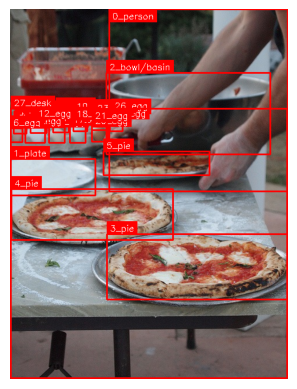

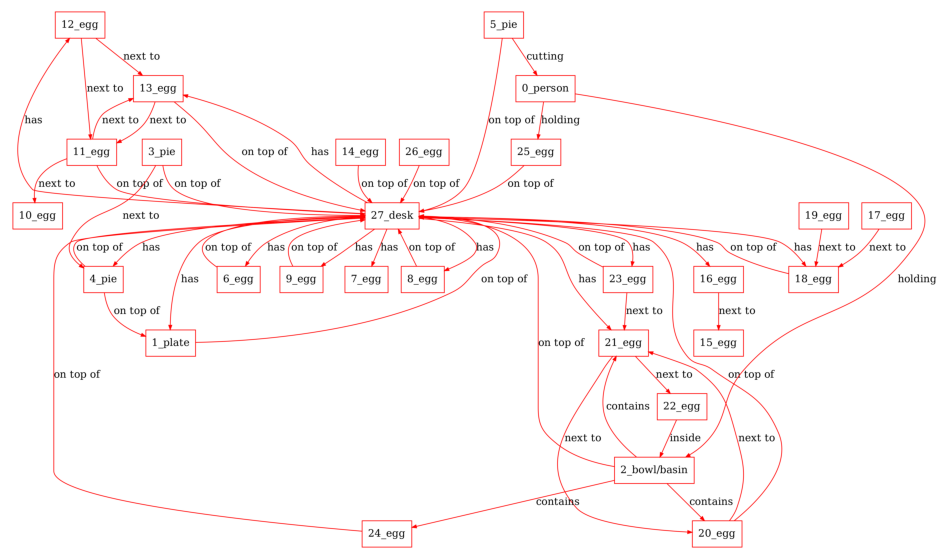

In [28]:
to_remove = []
img_data = [i for i in data if i['image_id'] == img_num][0]

current_rels = []
for r in img_data['relationships']:
    if r['predicate'] == None:
        to_remove.append(r)
        print(r)

    if (r['subject_id'], r['object_id']) not in current_rels:
        current_rels.append((r['subject_id'], r['object_id']))
    else:
        to_remove.append(r)

img_data['relationships'] = [x for x in img_data['relationships'] if x not in to_remove]

img_graph, img_boxes = visualize_graph(img_data['relationships'], img_data['objects'], img)

# visualize the box image
plt.imshow(img_boxes)
plt.axis('off')
plt.show()

# visualize the graph
fig = plt.figure(figsize=(12, 12))
plt.imshow(img_graph)
plt.axis('off')
plt.show()

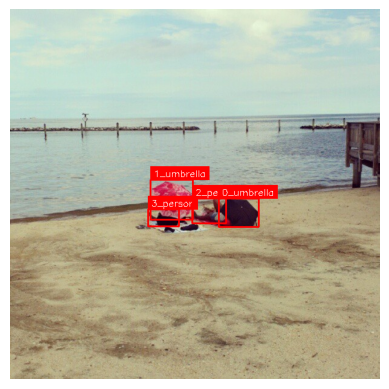

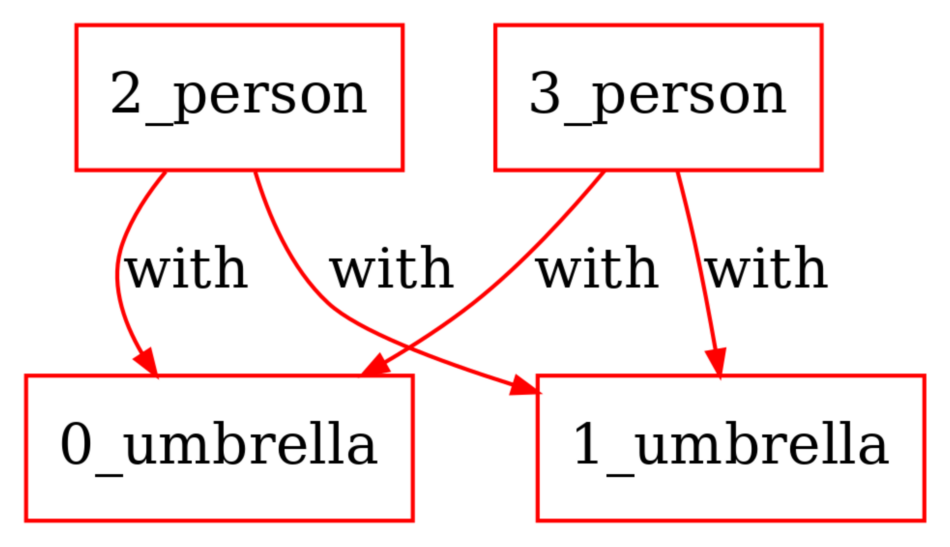

In [81]:
to_remove = []
img_data = [i for i in data if i['image_id'] == img_num][0]

current_rels = []
for r in img_data['relationships']:
    if r['predicate'] == None:
        to_remove.append(r)
        print(r)

    if (r['subject_id'], r['object_id']) not in current_rels:
        current_rels.append((r['subject_id'], r['object_id']))
    else:
        to_remove.append(r)

img_data['relationships'] = [x for x in img_data['relationships'] if x not in to_remove]

img_graph, img_boxes = visualize_graph(img_data['relationships'], img_data['objects'], img)

# visualize the box image
plt.imshow(img_boxes)
plt.axis('off')
plt.show()

# visualize the graph
fig = plt.figure(figsize=(12, 12))
plt.imshow(img_graph)
plt.axis('off')
plt.show()

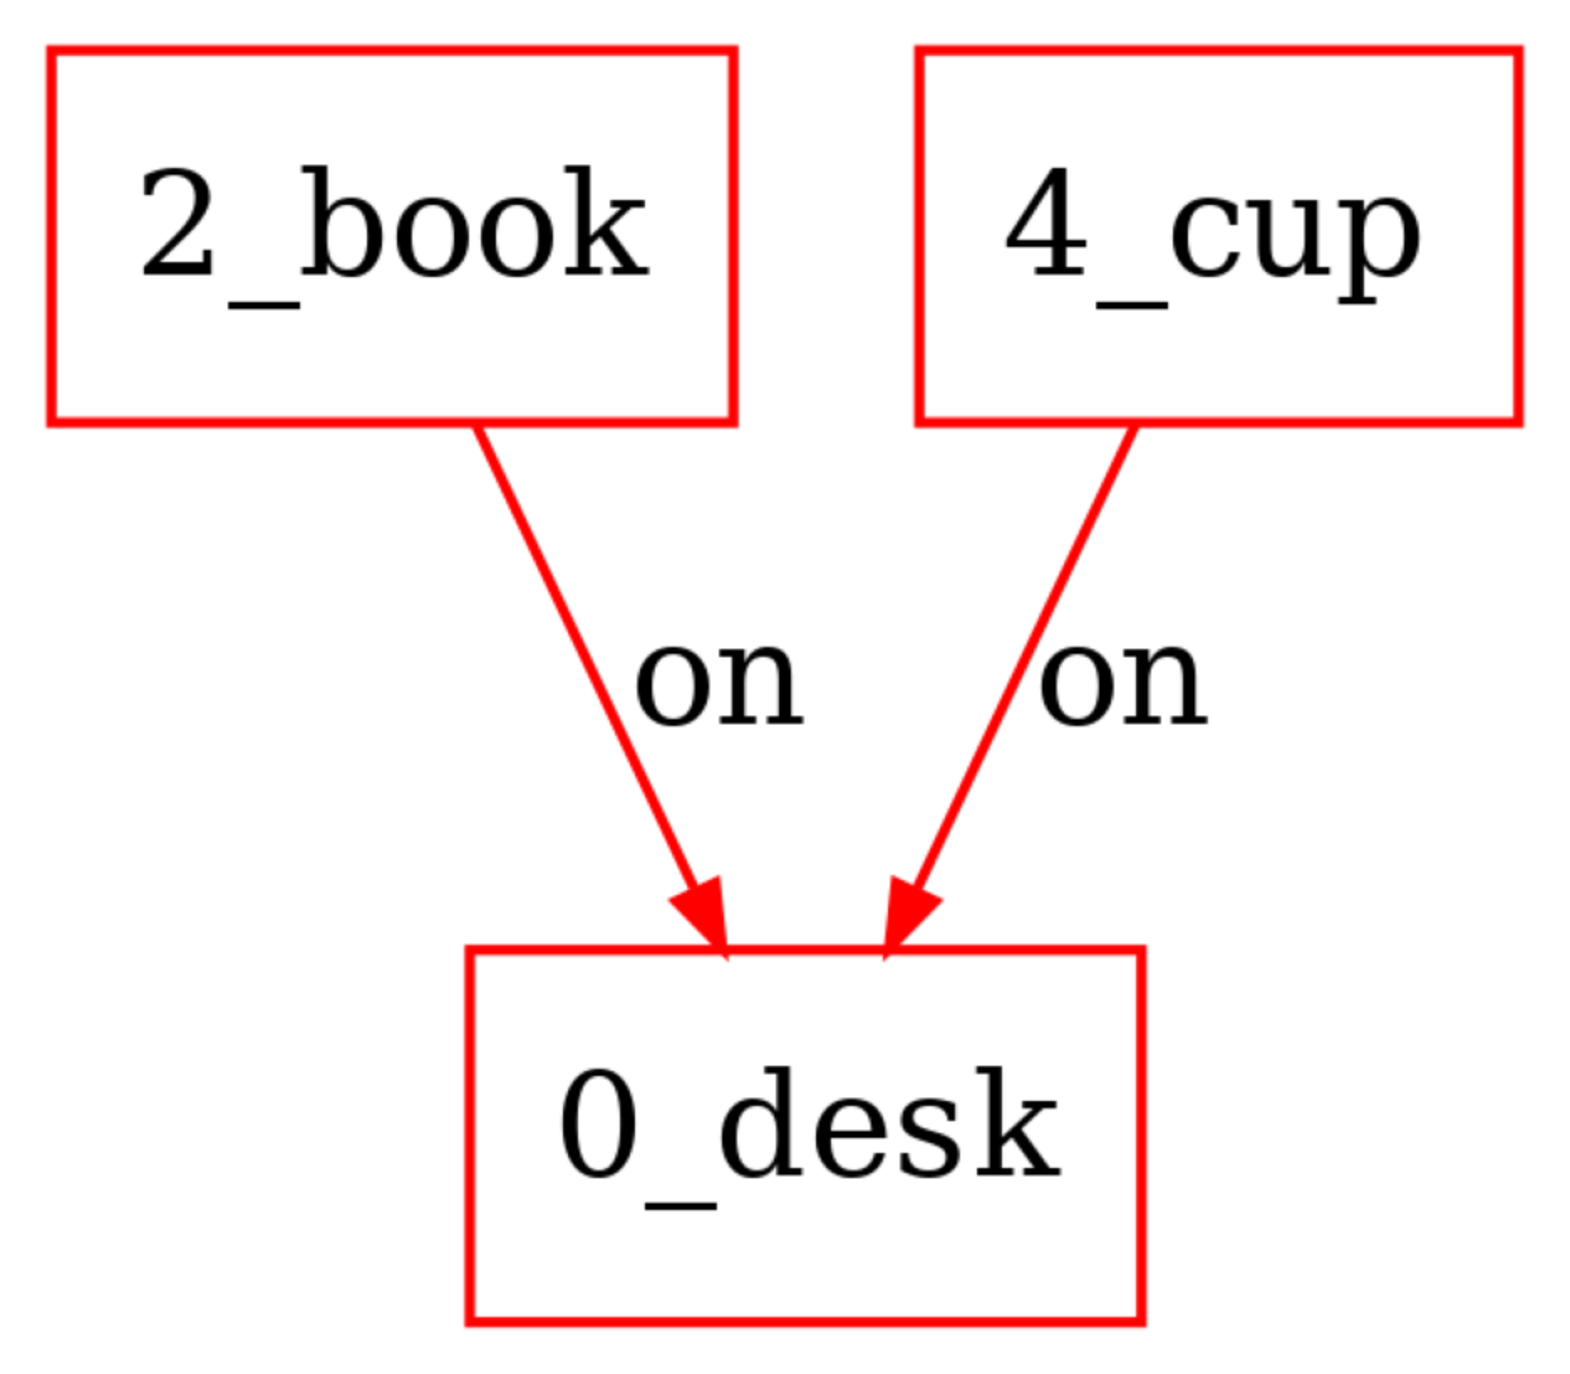

In [3]:
# visualize the graph
fig = plt.figure(figsize=(20, 20))
plt.imshow(img_graph)
plt.axis('off')
plt.show()

In [4]:
# get a random img id
while True:
    img_data = random.choice(data)
    if len(img_data['relationships']) > 0:
        break
img_id = img_data['image_id']
# put a lot of 0 in front of the id such that the total length is 12
img_id = str(img_id).zfill(12)
#img_id = "objects365_v2_" + img_id
split = img_data['data_split']

data_path = coco_img_path + split

# get corresponding img path
img_path = os.path.join(data_path, str(img_id) + ".jpg")

# get all objects pairs that intersect
objects = []
for obj in img_data['objects']:
    bbox = [obj['x'], obj['y'], obj['w'], obj['h']]
    objects.append({'bbox': bbox, 'label': obj['names']})

# compute intersection
def intersection(bbox1, bbox2):
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2

    x = max(x1, x2)
    y = max(y1, y2)
    w = min(x1 + w1, x2 + w2) - x
    h = min(y1 + h1, y2 + h2) - y

    # return boolean
    return w > 0 and h > 0

# compute intersection for all pairs
pairs = []
for i in range(len(objects)):
    for j in range(i+1, len(objects)):
        if i == j:
            continue
        if intersection(objects[i]['bbox'], objects[j]['bbox']):
            pairs.append((objects[i], objects[j]))

img = Image.open(img_path)

# show image
plt.imshow(img)
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/maelic/Documents/Datasets/coco/coco/train/000000000071.jpg'

[('next to', 399416), ('has', 78500), ('on', 72464), ('contains', 61569), ('on top of', 53867), ('near', 45805), ('behind', 40918), ('standing next to', 37190), ('holding', 33399), ('above', 25382)]
2092


/tmp/ipykernel_2578910/3622628412.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[i[0] for i in count_predicate.most_common(50)], y=[i[1] for i in count_predicate.most_common(50)], palette="viridis")


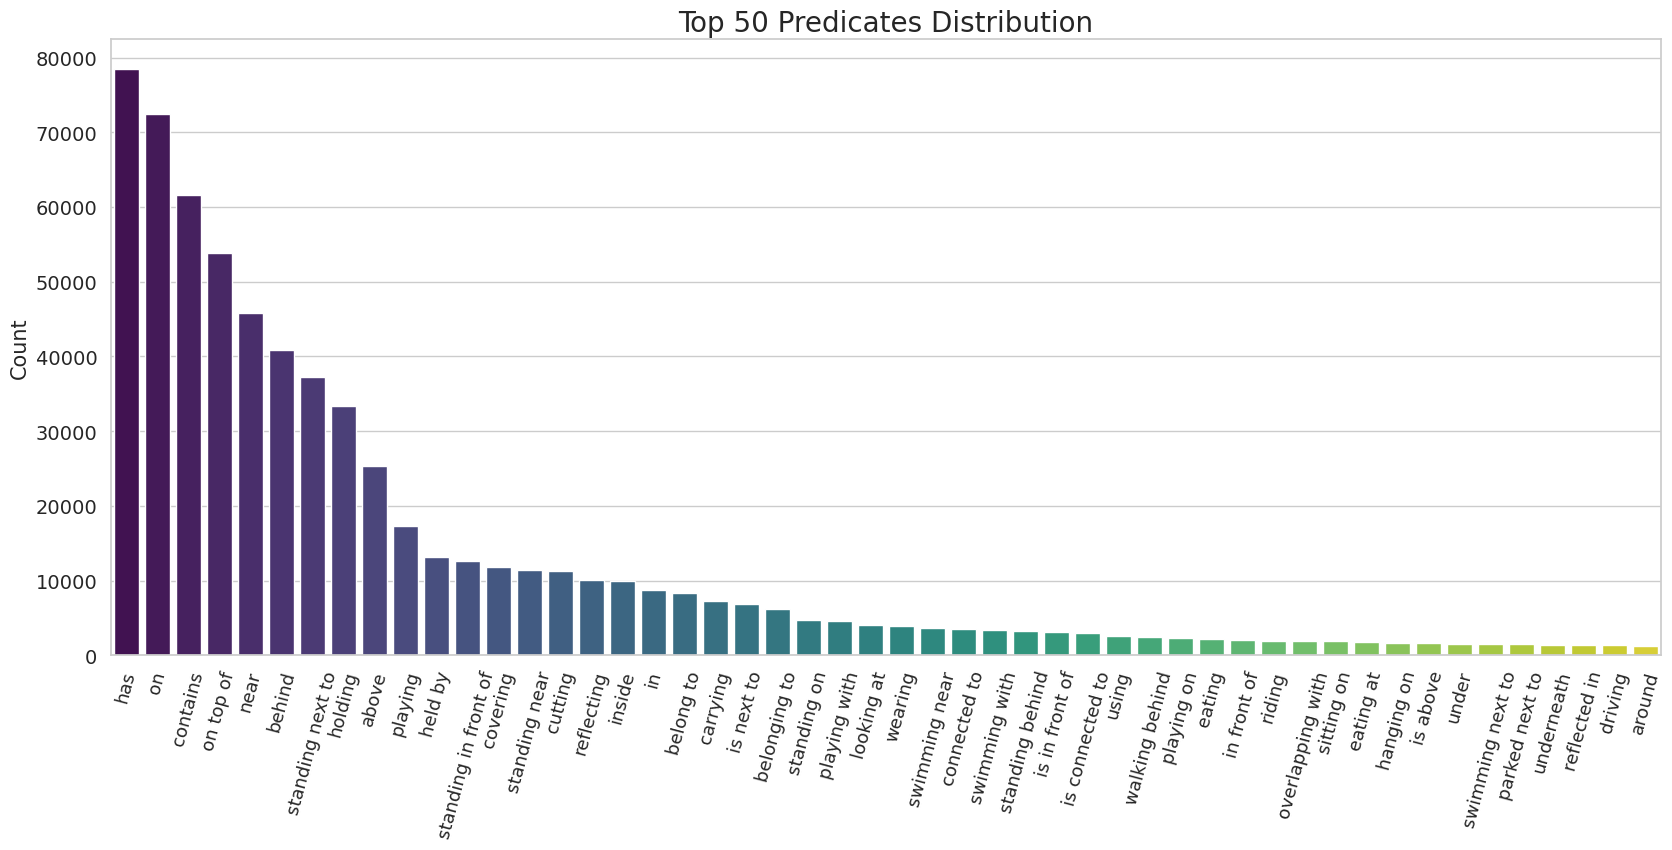

In [22]:
print(count_predicate.most_common(10))
print(len(count_predicate))

# remove first entry from count_predicate
count_predicate.pop('next to')

import seaborn as sns
import matplotlib.pyplot as plt

# display the distribution of the predicates
plt.figure(figsize=(20,8))
sns.set(style="whitegrid")

# Create the barplot
sns.barplot(x=[i[0] for i in count_predicate.most_common(50)], y=[i[1] for i in count_predicate.most_common(50)], palette="viridis")

# Add titles and labels
plt.title('Top 50 Predicates Distribution', fontsize=20)
# plt.xlabel('Predicates', fontsize=15)
plt.ylabel('Count', fontsize=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=75, fontsize=13)
plt.yticks(fontsize=14)

# Show the plot
plt.show()

In [23]:
# total num of rels
print(rel_count)

1123509


In [ ]:
print(data[101]['objects'])

# get the average number of objects per image

obj_count = 0
count_obj = Counter()

for i in tqdm(data):
    obj_count += len(i['objects'])
    for r in i['objects']:
        count_obj[r['names']] += 1

IndexError: list index out of range

/tmp/ipykernel_602037/398758548.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[i[0] for i in count_obj.most_common(50)], y=[i[1] for i in count_obj.most_common(50)], palette="viridis")


[('person', 110138), ('car', 19781), ('sky', 18780), ('tree', 18382), ('wall', 16231), ('chair', 13890), ('building', 11152), ('grass', 10631), ('pavement', 8724), ('bottle', 8120)]
133


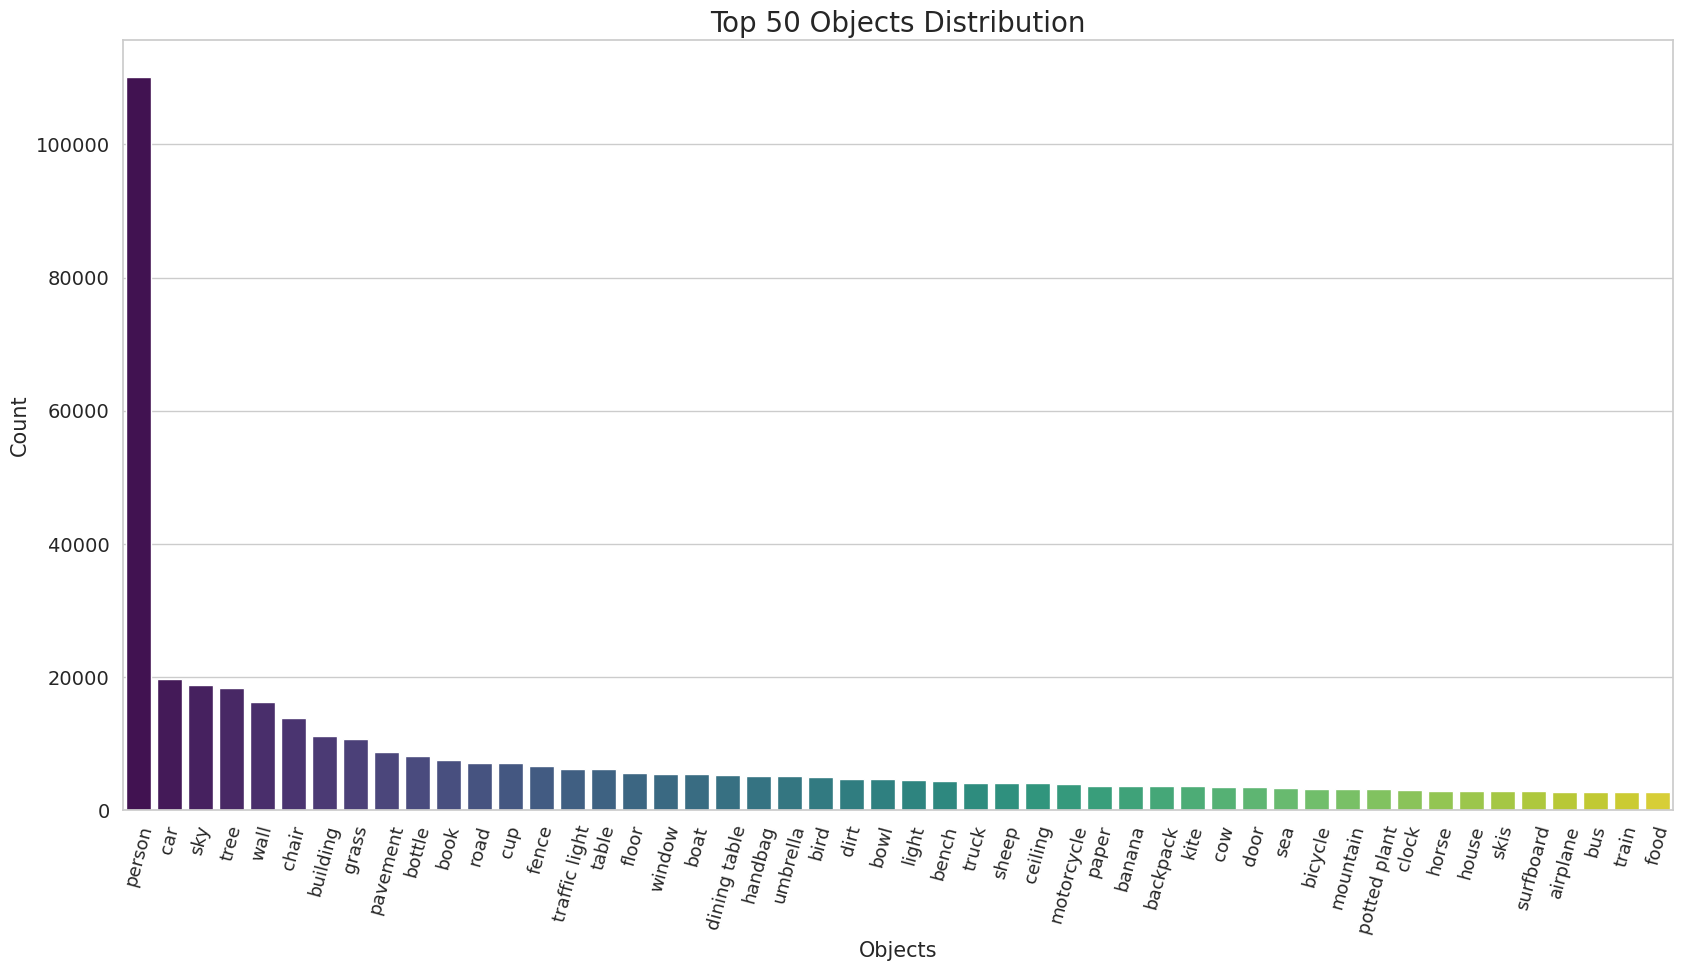

In [ ]:
print(count_obj.most_common(10))
print(len(count_obj))

import seaborn as sns
import matplotlib.pyplot as plt

# display the distribution of the objects

# display the distribution of the predicates
plt.figure(figsize=(20,10))
sns.set(style="whitegrid")

# Create the barplot
sns.barplot(x=[i[0] for i in count_obj.most_common(50)], y=[i[1] for i in count_obj.most_common(50)], palette="viridis")

# Add titles and labels
plt.title('Top 50 Objects Distribution', fontsize=20)
plt.xlabel('Objects', fontsize=15)
plt.ylabel('Count', fontsize=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=75, fontsize=13)
plt.yticks(fontsize=14)


# Show the plot
plt.show()

# plt.figure(figsize=(20,10))
# sns.barplot(x=[i[0] for i in count_obj.most_common(50)], y=[i[1] for i in count_obj.most_common(50)])
# plt.xticks(rotation=75)
# plt.show()